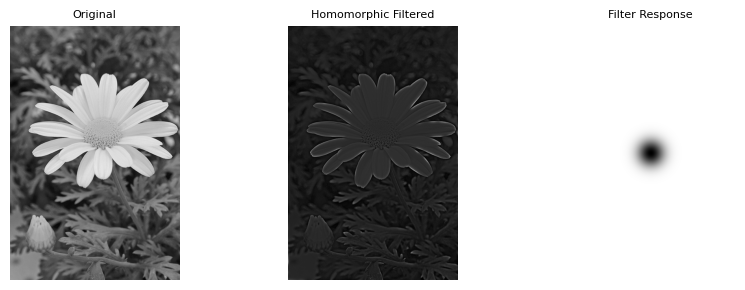

True

In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("q12_outputs", exist_ok=True)

#Homomorphic filtering function
def homomorphic_filter(img, sigma=30, gamma_l=0.5, gamma_h=2.0, c=1.0):
    #convert to float
    img = img.astype(np.float32)

    #log transform
    log_img = np.log1p(img)

    #Fourier transform
    fft = np.fft.fft2(log_img)
    fft_shift = np.fft.fftshift(fft)

    #Create high-pass filter
    rows, cols = img.shape
    crow, ccol = rows // 2, cols // 2

    y, x = np.ogrid[:rows, :cols]
    d2 = (y - crow) ** 2 + (x - ccol) ** 2

    H = (gamma_h - gamma_l) * (1 - np.exp(-c * d2 / (2 * sigma**2))) + gamma_l

    #Apply filter
    filtered_shift = H * fft_shift

    #Inverse Fourier transform
    ifft_shift = np.fft.ifftshift(filtered_shift)
    img_back = np.fft.ifft2(ifft_shift)
    img_back = np.real(img_back)

    #Exponential transform
    exp_img = np.expm1(img_back)

    #Normalize to 0-255
    exp_img = cv.normalize(exp_img, None, 0, 255, cv.NORM_MINMAX)
    exp_img = np.uint8(exp_img)

    return log_img, H, exp_img

#Load image
img = cv.imread("/content/daisy.jpg", cv.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError("Check the image path")

#Apply homomorphic filtering
log_img, H, corrected = homomorphic_filter(img, sigma=30, gamma_l=0.5, gamma_h=2.0, c=1.0)

# -----------------------------------
# Compact display
# -----------------------------------
plt.figure(figsize=(9, 3))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original", fontsize=8)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(corrected, cmap="gray")
plt.title("Homomorphic Filtered", fontsize=8)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(H, cmap="gray")
plt.title("Filter Response", fontsize=8)
plt.axis("off")

plt.tight_layout()
plt.savefig("q12_outputs/q12_results.png", dpi=300, bbox_inches="tight")
plt.show()

# Save separate outputs
cv.imwrite("q12_outputs/q12_original.png", img)
cv.imwrite("q12_outputs/q12_corrected.png", corrected)